# asses the history of runs


In [59]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path


/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


## Test of disc density plotting

In [ ]:
import sys
import os
import argparse
from astropy.io import fits
import numpy as np
import scipy
import glob
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

#function to plot 2D disk structure profiles
#note that 'az_disk' now stands for the azimuthal cut considered in the disk
#not the azimuthal angle under which the system is viewed (like for SED and image plotting)
def plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=False):
    #make folder to store images if needed
    if save_plots==True and os.path.exists(main_dir+sub_dir+'/figures')==False:
        os.system("mkdir "+main_dir+sub_dir+'/figures')

    #open the required grid structure file
    hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
    grid_struct=hdul[0].data
    #note we don't check for dimensionality because it's always 4D for this file
    #extract cylindrical radius and height above midplane of computation grid cell
    r = grid_struct[0, az_disk, :, :]
    z = grid_struct[1, az_disk, :, :]

    #open the required temperature, dust and gas mass density fits files and plot them
    paths=['data_th/Temperature.fits.gz', 'data_disk/dust_mass_density.fits.gz', 'data_disk/gas_density.fits.gz']
    fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
    for i, path in enumerate(paths):
        hdul=fits.open(main_dir+sub_dir+path)
        quantity_struct=hdul[0].data
        #see if we're dealing with different azimuthal zones by checking dimesnionality
        #of file & select data out of hdu accordingly
        if quantity_struct.ndim > 2:
            quantity = quantity_struct[az_disk, :, :]
        else:
            quantity = quantity_struct[:, :]

        #plotting
        cmesh = ax[i].pcolormesh(r, z, quantity, cmap='viridis', norm=LogNorm())
        cb = plt.colorbar(cmesh, ax=ax[i])
        if path == 'data_th/Temperature.fits.gz':
            cb.set_label(r'$T \, \mathrm{[K]}$')
        elif path == 'data_disk/dust_mass_density.fits.gz':
            cb.set_label(r'$\rho_{dust} \, \mathrm{[g \, cm^{-3}]}$')
        elif path == 'data_disk/gas_density.fits.gz':
            cb.set_label(r'$\rho_{gas} \, \mathrm{[g \, cm^{-3}]}$')
        ax[i].set_xlabel(r'$r \, \mathrm{[AU]}$')
        #ax[i].set_yscale('log')

        ax[i].set_ylabel(r'$z \, \mathrm{[AU]}$')
        ax[i].set_xlim(0, np.max(r))
        
    plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
    #save the plot
    plt.tight_layout()
    if save_plots==True:
        fig.savefig(main_dir+sub_dir+'figures/disk_structure2D'+'_az_zone'+str(az_disk)+'.png', dpi= 100, bbox_inches='tight')


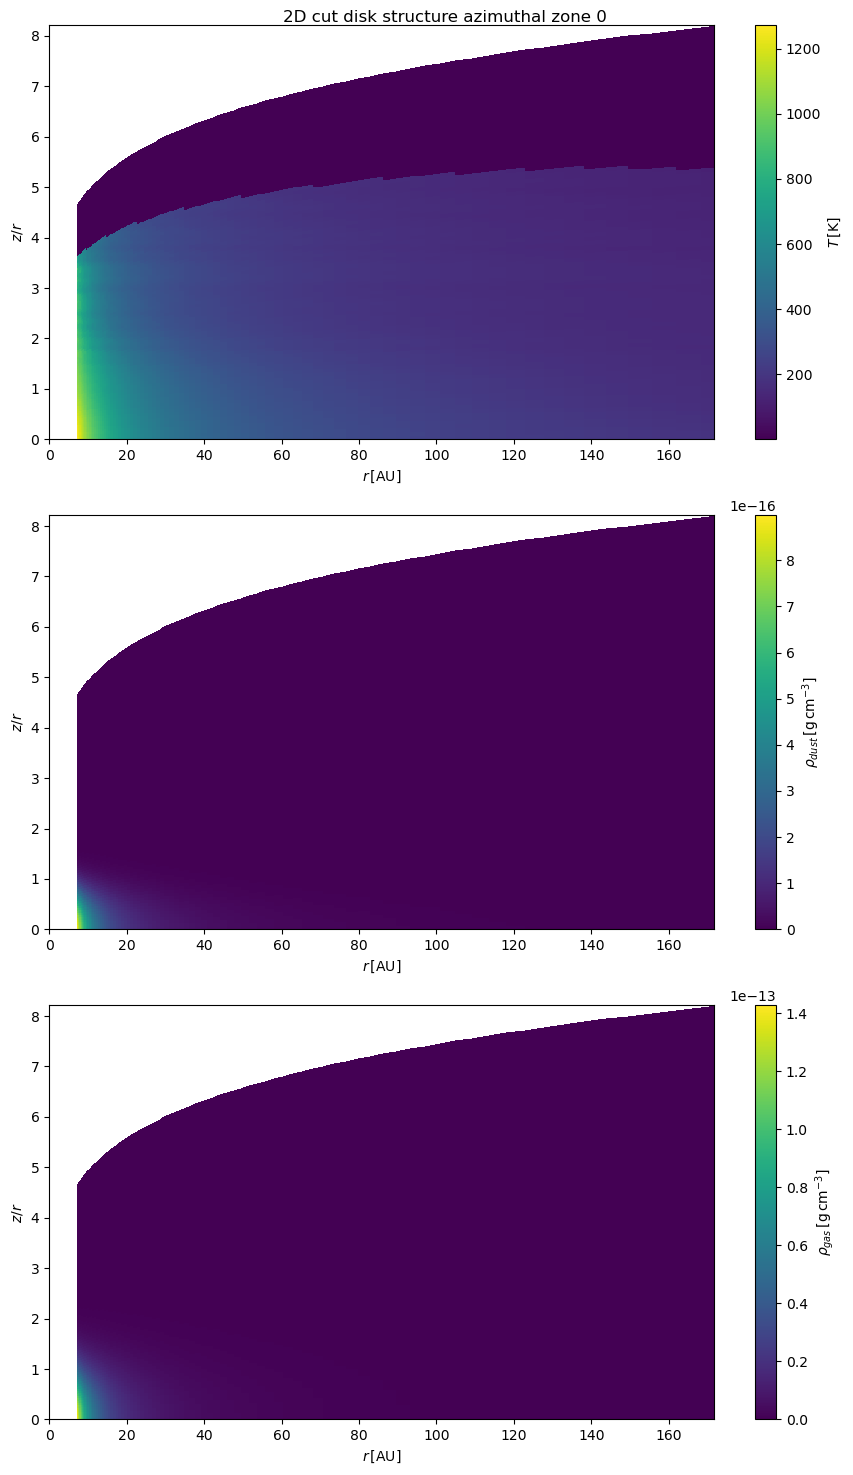

In [25]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260501_no_puffed_rim_budget1/smac_results/"
sub_dir=""

plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


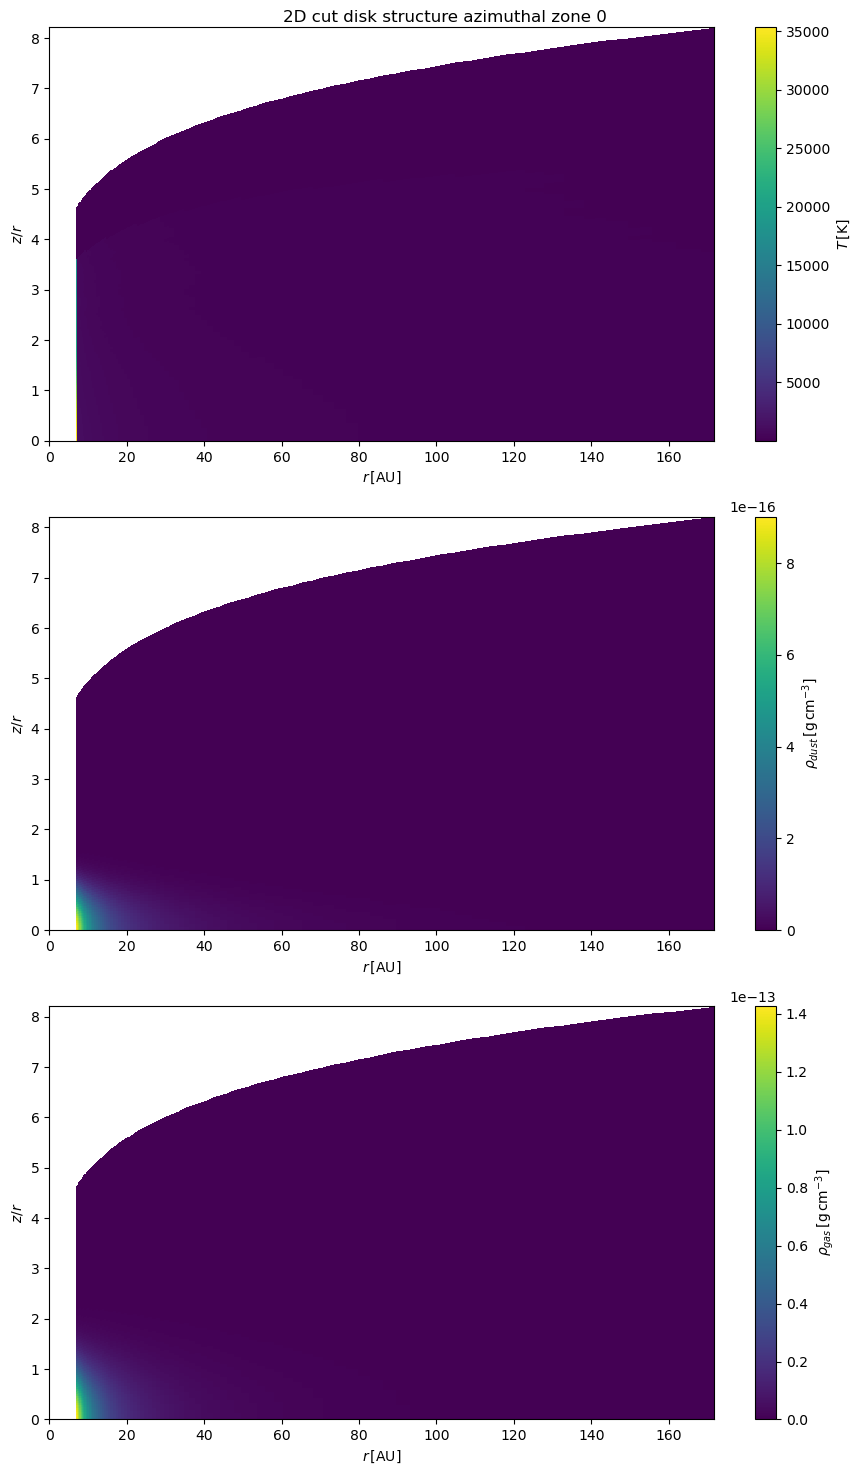

In [27]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260610_no_puffed_rim_migration_sublim/"
sub_dir=""

plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


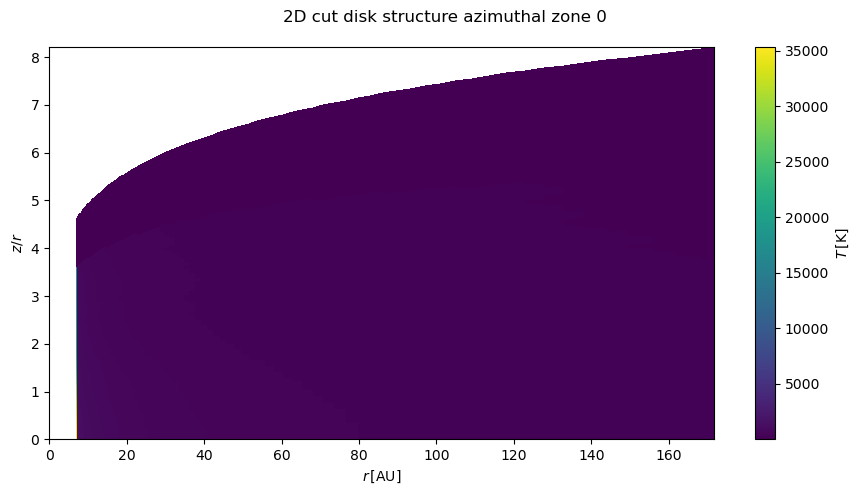

In [44]:
az_disk=0
hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
grid_struct=hdul[0].data
#note we don't check for dimensionality because it's always 4D for this file
#extract cylindrical radius and height above midplane of computation grid cell
r = grid_struct[0, az_disk, :, :]
z = grid_struct[1, az_disk, :, :]

#open the required temperature, dust and gas mass density fits files and plot them
paths=['data_th/Temperature.fits.gz']
fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
for i, path in enumerate(paths):
    hdul=fits.open(main_dir+sub_dir+path)
    quantity_struct=hdul[0].data
    #see if we're dealing with different azimuthal zones by checking dimesnionality
    #of file & select data out of hdu accordingly
    if quantity_struct.ndim > 2:
        quantity = quantity_struct[az_disk, :, :]
    else:
        quantity = quantity_struct[:, :]
    
    #plotting
    cmesh = ax.pcolormesh(r, z/r, quantity, cmap='viridis')
    cb = plt.colorbar(cmesh, ax=ax)
    
    cb.set_label(r'$T \, \mathrm{[K]}$')
    ax.set_xlabel(r'$r \, \mathrm{[AU]}$')
    ax.set_ylabel(r'$z/r$')
    ax.set_xlim(0, np.max(r))
        
    plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
    #save the plot
    plt.tight_layout()
    plt.show()

    

In [43]:
quantity_struct.max()


35345.6

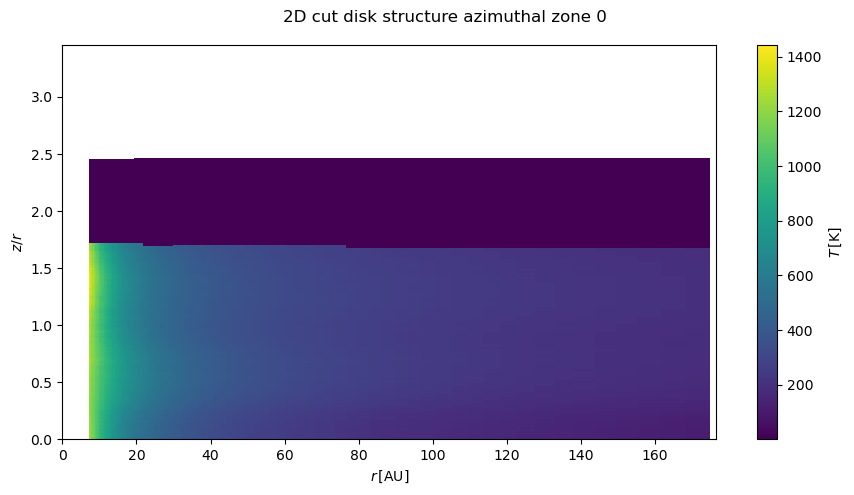

In [10]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260501_puffed_rim_broad_budget1/smac_results/"
sub_dir=""



az_disk=0
hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
grid_struct=hdul[0].data
#note we don't check for dimensionality because it's always 4D for this file
#extract cylindrical radius and height above midplane of computation grid cell
r = grid_struct[0, az_disk, :, :]
z = grid_struct[1, az_disk, :, :]

#open the required temperature, dust and gas mass density fits files and plot them
paths=['data_th/Temperature.fits.gz']
fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
for i, path in enumerate(paths):
    hdul=fits.open(main_dir+sub_dir+path)
    quantity_struct=hdul[0].data
    #see if we're dealing with different azimuthal zones by checking dimesnionality
    #of file & select data out of hdu accordingly
    if quantity_struct.ndim > 2:
        quantity = quantity_struct[az_disk, :, :]
    else:
        quantity = quantity_struct[:, :]
    
    #plotting
    cmesh = ax.pcolormesh(r, z/r, quantity, cmap='viridis')
    cb = plt.colorbar(cmesh, ax=ax)
    
    cb.set_label(r'$T \, \mathrm{[K]}$')
    ax.set_xlabel(r'$r \, \mathrm{[AU]}$')
    ax.set_ylabel(r'$z/r$')
    ax.set_xlim(0, np.max(r)+5)
    ax.set_ylim(0, np.max(z/r)+1)
        
    plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
    #save the plot
    plt.tight_layout()
    plt.show()

    

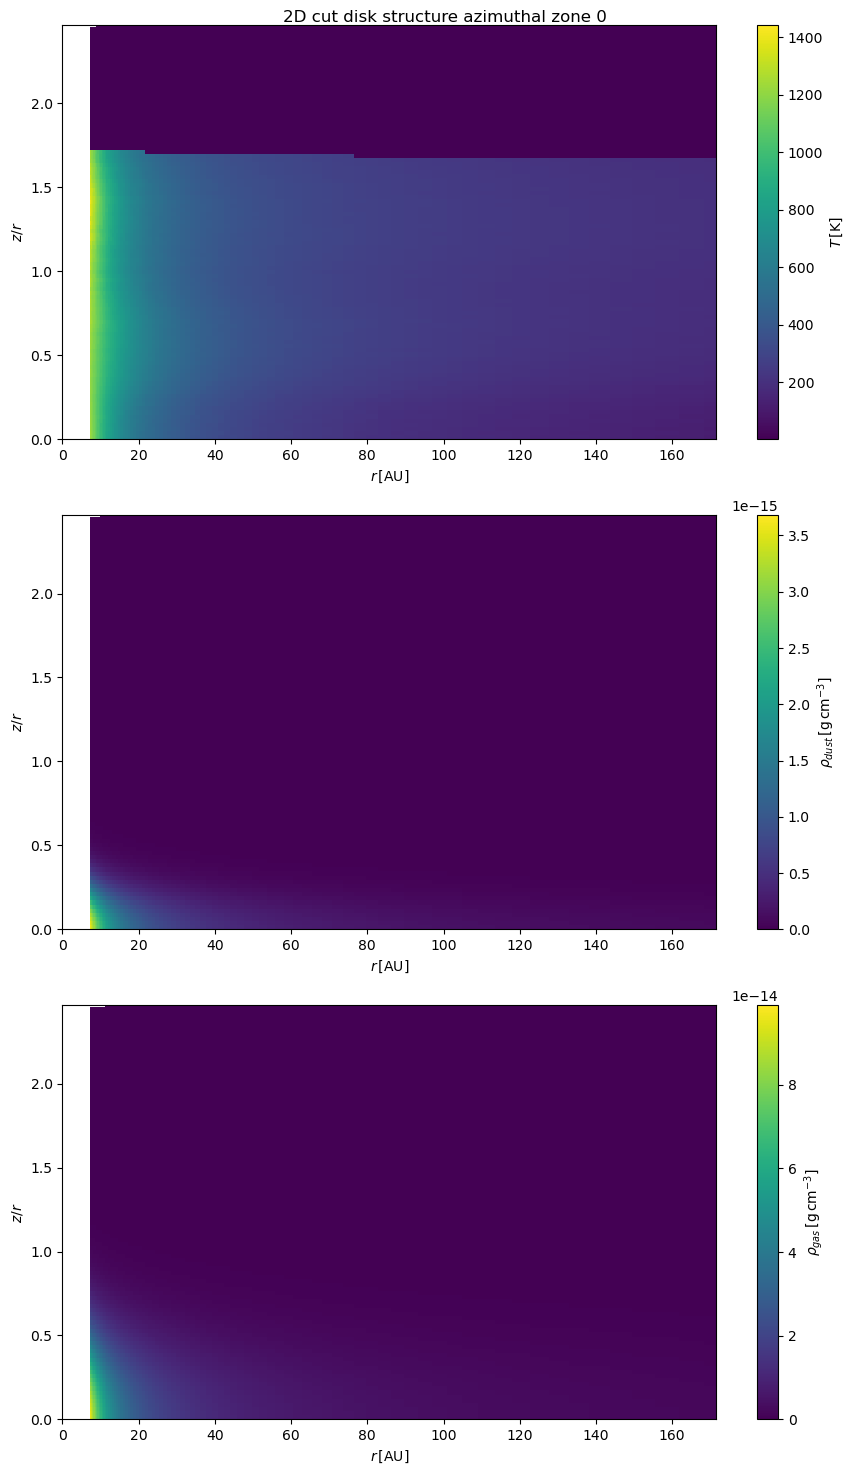

In [ ]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260501_puffed_rim_broad_budget1/smac_results/"
sub_dir=""


plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


## test on structure


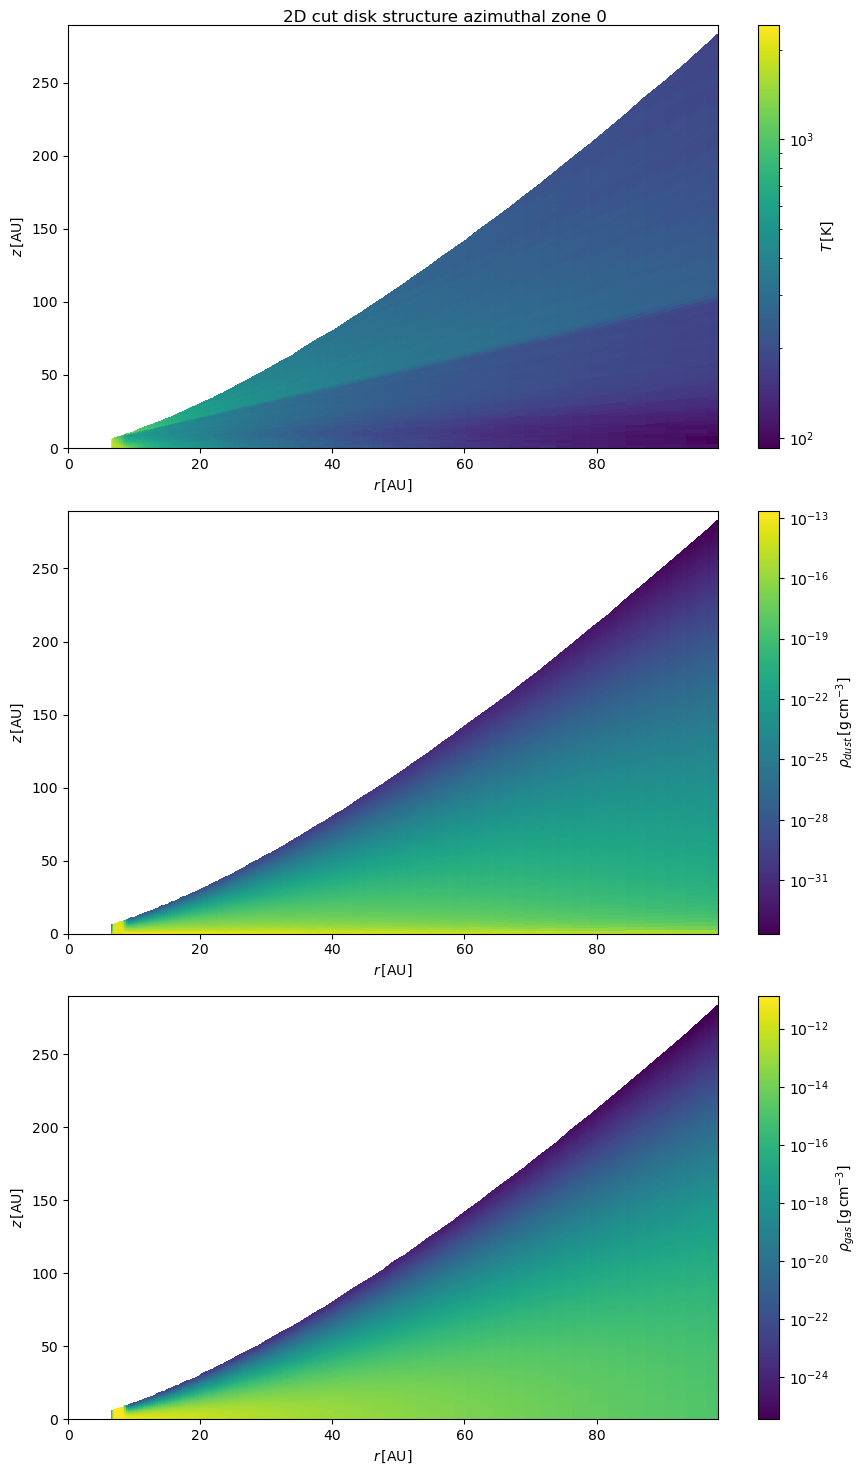

In [133]:
main_dir="/fred/oz061/kandrych/smac/check_density/inner_rim/"
sub_dir=""


plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


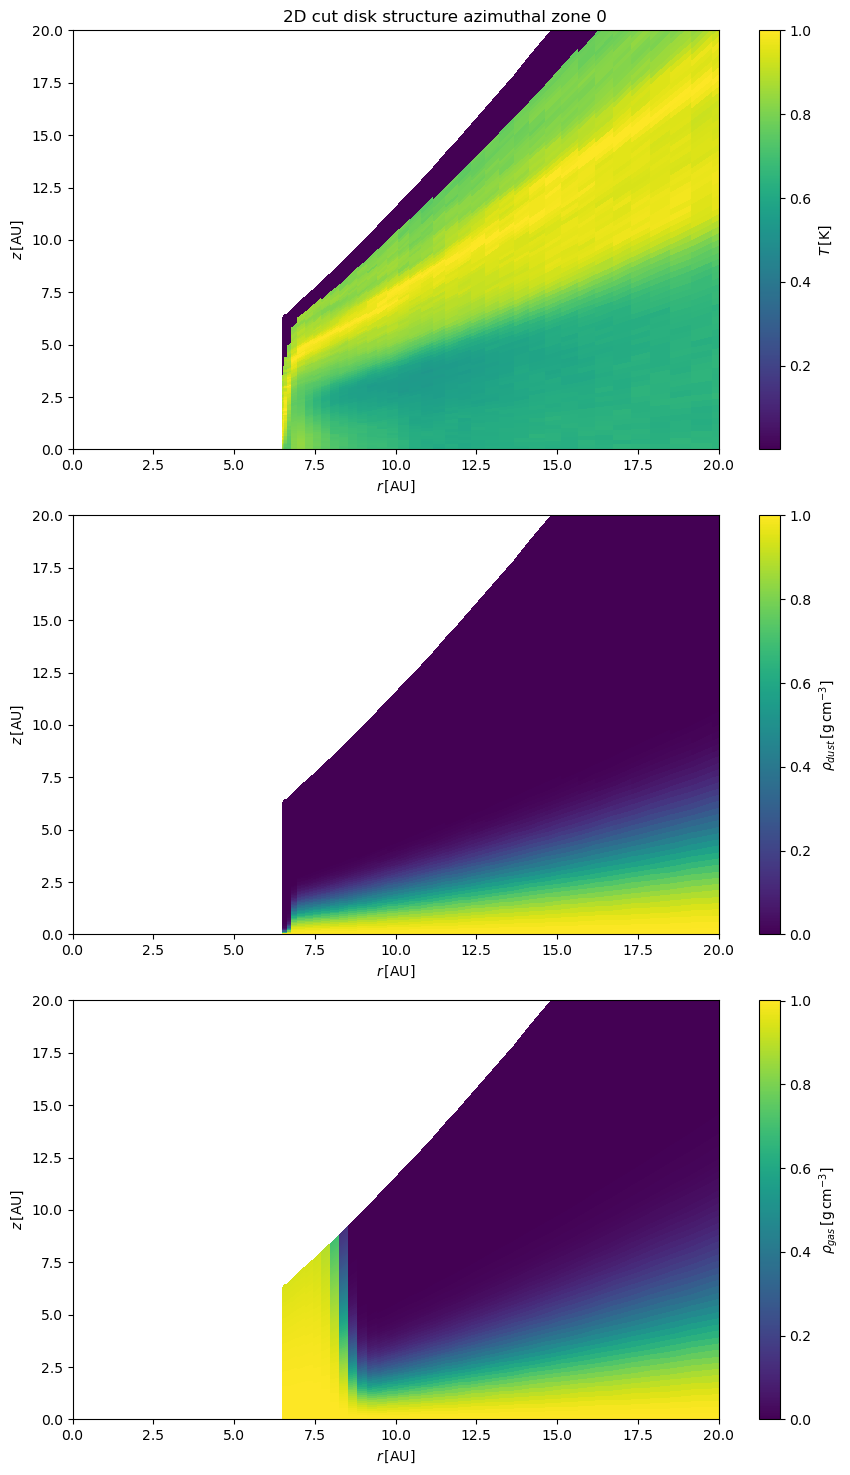

In [135]:

az_disk=0
hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
grid_struct=hdul[0].data
#note we don't check for dimensionality because it's always 4D for this file
#extract cylindrical radius and height above midplane of computation grid cell
r = grid_struct[0, az_disk, :, :]
z = grid_struct[1, az_disk, :, :]

paths=['data_th/Temperature.fits.gz', 'data_disk/dust_mass_density.fits.gz', 'data_disk/gas_density.fits.gz']
fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
for i, path in enumerate(paths):
    hdul=fits.open(main_dir+sub_dir+path)
    quantity_struct=hdul[0].data
    #see if we're dealing with different azimuthal zones by checking dimesnionality
    #of file & select data out of hdu accordingly
    if quantity_struct.ndim > 2:
        quantity = quantity_struct[az_disk, :, :]
    else:
        quantity = quantity_struct[:, :]
    q_norm = quantity / np.nanmax(quantity, axis=0)[None, :]

    #plotting
    cmesh = ax[i].pcolormesh(r, z, q_norm, cmap='viridis')
    cb = plt.colorbar(cmesh, ax=ax[i])
    if path == 'data_th/Temperature.fits.gz':
        cb.set_label(r'$T \, \mathrm{[K]}$')
    elif path == 'data_disk/dust_mass_density.fits.gz':
        cb.set_label(r'$\rho_{dust} \, \mathrm{[g \, cm^{-3}]}$')
    elif path == 'data_disk/gas_density.fits.gz':
        cb.set_label(r'$\rho_{gas} \, \mathrm{[g \, cm^{-3}]}$')
    ax[i].set_xlabel(r'$r \, \mathrm{[AU]}$')
    #ax[i].set_yscale('log')

    ax[i].set_ylabel(r'$z \, \mathrm{[AU]}$')
    ax[i].set_xlim(0, 20)
    ax[i].set_ylim(0, 20)
    
plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
#save the plot
plt.tight_layout()
plt.show()


## Density plots


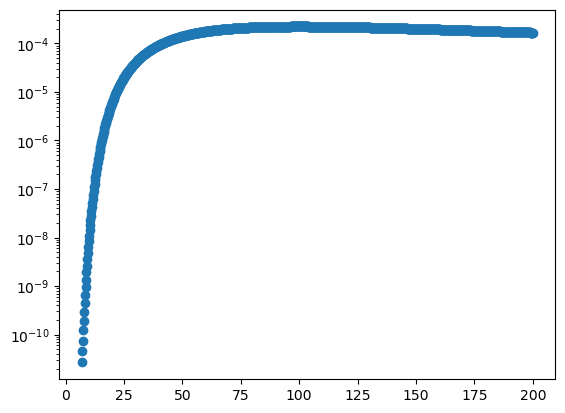

In [149]:
p1=-1.5
p2=-3
Rc=150
r=np.linspace(7, 200, 1000)
sigma=r**p1*np.exp(-(r/Rc)**(2+p2))

plt.scatter(r, sigma)

plt.yscale('log')

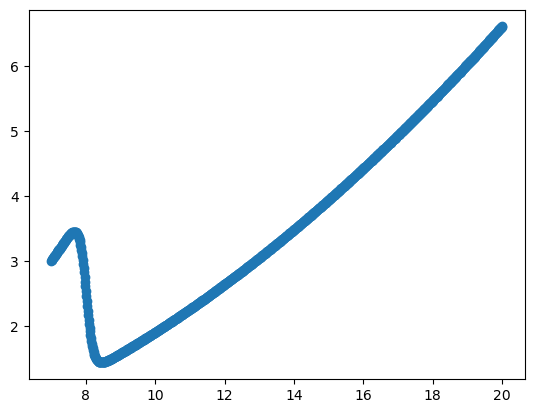

In [97]:
h0=1
r0=7
hrimh0=3
rrim=8
delta_r=0.1
flaring_factor=1.8
r=np.linspace(7, 20, 1000)

h0r=h0*(r/r0)**flaring_factor

h=h0r*(1+(hrimh0 -1)/(np.exp((r-rrim)/delta_r)+1))

plt.scatter(r, h)
#plt.yscale('log')